In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

pd.set_option('display.max_columns', None)

In [11]:
# Read the CSV file into a DataFrame
travel_data = pd.read_csv('../source-data/travel_data.csv', parse_dates=['Travel_Date', 'Booking_Date', 'Booking_Timestamp'])

# check how many rows and columns we have
travel_data.shape

(519713, 25)

519713 rows and 25 columns

In [7]:
travel_data.head()

,Booking_ID,Customer_ID,Route_ID,Travel_Date,Booking_Date,Booking_Timestamp,Ticket_Price_GBP,Seat_Class,Booking_Channel,Origin,Destination,Distance_km,Route_Category,Customer_Segment,Loyalty_Status,Booking_Frequency_Qtr,Average_Spend_GBP,Total_Seats,Seats_Sold_Realized,Remaining_Seats_Realized,Demand_Index,Base_Price_At_Booking,Days_Before_Travel,Price_Premium,Load_Factor
0,B000000087,C000971,R0001,2025-01-01,2024-11-03,2024-11-03 02:38:21,51.81,Standard,Web,Aberdeen,Leeds,264,Medium,Leisure,NaN,2,17.61,283,167,116,0.798,NaN,58,NaN,0.590106
1,B000000012,C004636,R0001,2025-01-01,2024-11-10,2024-11-10 21:51:11,53.74,Standard,Web,Aberdeen,Leeds,264,Medium,Leisure,Gold,2,41.66,283,167,116,0.798,NaN,51,NaN,0.590106
2,B000000021,C004403,R0001,2025-01-01,2024-11-15,2024-11-15 23:24:12,69.01,Flex,Web,Aberdeen,Leeds,264,Medium,Leisure,NaN,2,39.07,283,167,116,0.798,NaN,46,NaN,0.590106
3,B000000064,C010229,R0001,2025-01-01,2024-11-18,2024-11-18 00:18:54,98.86,First,Mobile,Aberdeen,Leeds,264,Medium,Leisure,NaN,4,45.29,283,167,116,0.798,NaN,43,NaN,0.590106
4,B000000077,C009319,R0001,2025-01-01,2024-11-18,2024-11-18 15:02:18,56.89,Standard,Mobile,Aberdeen,Leeds,264,Medium,Leisure,NaN,4,50.49,283,167,116,0.798,NaN,43,NaN,0.590106


Already seeing some null values

In [12]:
# check the data types and missing values for each column
travel_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 519713 entries, 0 to 519712
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   Booking_ID                519713 non-null  str           
 1   Customer_ID               519713 non-null  str           
 2   Route_ID                  519713 non-null  str           
 3   Travel_Date               519713 non-null  datetime64[us]
 4   Booking_Date              519713 non-null  datetime64[us]
 5   Booking_Timestamp         519713 non-null  datetime64[us]
 6   Ticket_Price_GBP          519713 non-null  float64       
 7   Seat_Class                519713 non-null  str           
 8   Booking_Channel           519713 non-null  str           
 9   Origin                    519713 non-null  str           
 10  Destination               519713 non-null  str           
 11  Distance_km               519713 non-null  int64         
 12  Route_Categor

Columns with null values are Loyalty_Status, Base_Price_At_Booking and Price_Premium 

Text(0.5, 1.0, 'Ticket Price vs Demand Index')

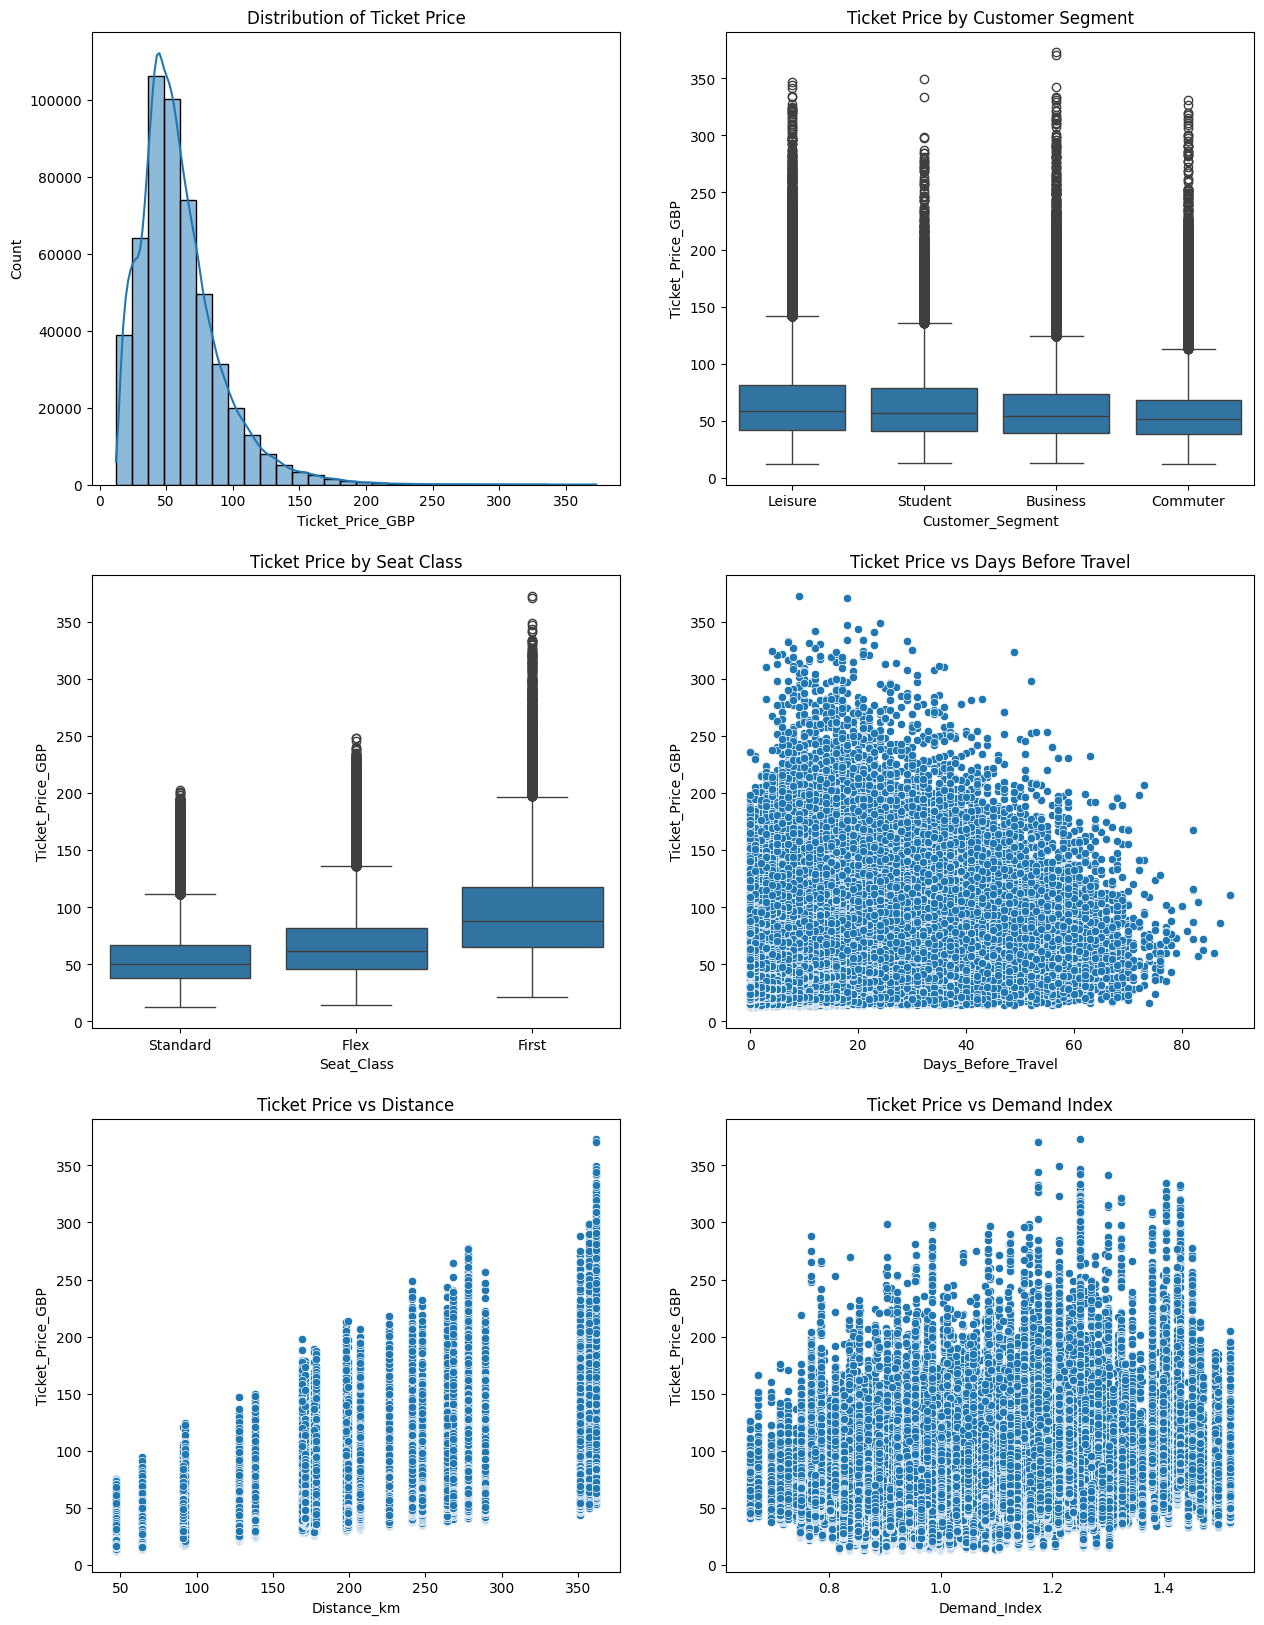

In [22]:
fig, axes = plt.subplots(3, 2, figsize=(15, 20))

# Plot the distribution of Ticket_Price
sns.histplot(travel_data['Ticket_Price_GBP'], bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Ticket Price')

# Plot boxplot of Ticket_Price by Customer_Segment
sns.boxplot(x='Customer_Segment', y='Ticket_Price_GBP', data=travel_data, ax=axes[0, 1])
axes[0, 1].set_title('Ticket Price by Customer Segment')

# boxplpot of Ticket_Price by Seat_Class
sns.boxplot(x='Seat_Class', y='Ticket_Price_GBP', data=travel_data, ax=axes[1, 0])
axes[1, 0].set_title('Ticket Price by Seat Class')

# scatter plot of Ticket_Price vs days before travel
sns.scatterplot(x='Days_Before_Travel', y='Ticket_Price_GBP', data=travel_data, ax=axes[1, 1])
axes[1, 1].set_title('Ticket Price vs Days Before Travel')

# sctatter plot of Ticket_Price vs Distance
sns.scatterplot(x='Distance_km', y='Ticket_Price_GBP', data=travel_data, ax=axes[2, 0])
axes[2, 0].set_title('Ticket Price vs Distance')

# scatter plot of Ticket_Price vs Demand Index
sns.scatterplot(x='Demand_Index', y='Ticket_Price_GBP', data=travel_data, ax=axes[2, 1])
axes[2, 1].set_title('Ticket Price vs Demand Index')

# Initial Findings

- Ticket Price is normally between £40 and £60 frm distribution. The distribution is also right-skewed.
- Slight correlation between price and days before travel
- No correlation between price and distance. Its unaffected by distance
- Ticket pricing is unaffected too by demand index, confirming the existence of the problem we're trying t solve.
- No percieved outlier as noted by boxplots

In [ ]:
# Confirm that there are no outliers in featured columns using mean and median
travel_data.describe(include=['int64', 'float64'])

,Ticket_Price_GBP,Distance_km,Booking_Frequency_Qtr,Average_Spend_GBP,Total_Seats,Seats_Sold_Realized,Remaining_Seats_Realized,Demand_Index,Base_Price_At_Booking,Days_Before_Travel,Price_Premium,Load_Factor
count,519713.000000,519713.000000,519713.000000,519713.000000,519713.000000,519713.000000,519713.000000,519713.000000,461445.000000,519713.000000,461445.000000,519713.000000
mean,59.949484,203.925224,5.122545,41.592756,308.997237,254.470173,54.527064,1.070136,52.871776,7.849571,5.394408,0.823364
std,30.365550,86.959412,2.776248,17.236907,71.364323,74.822934,45.034976,0.176269,24.313223,10.580809,11.720304,0.137679
min,12.290000,47.000000,0.000000,10.000000,140.000000,81.000000,3.000000,0.658000,13.360000,0.000000,-14.220000,0.332308
25%,39.800000,169.000000,3.000000,29.780000,258.000000,194.000000,11.000000,0.940000,36.970000,0.000000,-0.310000,0.723810
50%,54.150000,198.000000,5.000000,38.880000,319.000000,248.000000,47.000000,1.055000,49.060000,4.000000,1.060000,0.839161
75%,73.670000,264.000000,7.000000,50.060000,365.000000,315.000000,84.000000,1.190000,64.820000,11.000000,6.490000,0.961686
max,372.860000,362.000000,18.000000,125.520000,420.000000,412.000000,235.000000,1.520000,186.110000,89.000000,191.110000,0.982857


Since mean is sensitive to outliers, we can detect its presence (outlier) if the value of the mean is far off from the median. This doesn't appear to be the case with our columns.